In [558]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import xlabel
import matplotlib.pyplot as plt


enzyme_start_conc = 100 #nm

enzyme_final_conc = 5

buffer_volume = 100

reaction_volume = 250

enzyme_start_volume = (enzyme_final_conc * reaction_volume) / enzyme_start_conc

print(f"volume of enzyme: {enzyme_start_volume} uL")

substrate_start_conc = 10 #mM

#substrate_start_volume = 40 #uL
#substrate_final_conc = 3.793
substrate_start_volume = 100
substrate_final_conc = (substrate_start_conc * substrate_start_volume) / reaction_volume


#print(f"substrate concentration: {substrate_final_conc} mM")
print(f"concentration of the substrate: {substrate_final_conc} mM")
water_volume = reaction_volume - buffer_volume - substrate_start_volume  - enzyme_start_volume

total_volume = buffer_volume + substrate_start_volume + water_volume + enzyme_start_volume

print(f"water volume: {water_volume} uL")

print(total_volume)

volume of enzyme: 12.5 uL
concentration of the substrate: 4.0 mM
water volume: 37.5 uL
250.0


In [559]:
volume_of_dilute = (200 * 120)/ enzyme_start_conc
print(volume_of_dilute)

240.0


# Testing of our reaction mixer

In [560]:
ex_5_general_test = pd.read_csv("ex5test2.csv", sep=";", decimal=',')

reduced_ex5_general_test = ex_5_general_test.iloc[:, :]

array_ex5_general_test = reduced_ex5_general_test.to_numpy()
print(array_ex5_general_test)

[['A' 0.051 0.05 0.05 0.05 0.051 0.05 0.05 0.05 0.05 0.05 0.05 0.05 410]
 ['B' 0.05 0.05 0.049 0.049 0.05 0.05 0.05 0.057 0.05 0.05 0.05 0.05 410]
 ['C' 0.051 0.05 0.05 0.05 0.051 0.05 0.05 0.05 0.05 0.05 0.05 0.05 410]
 ['D' 0.051 0.05 0.05 0.051 0.05 0.05 0.05 0.05 0.051 0.05 0.05 0.051 410]
 ['E' 0.061 0.05 0.05 0.051 0.051 0.051 0.05 0.053 0.051 0.05 0.05 0.051
  410]
 ['F' 3.465 3.652 3.641 3.663 0.051 0.05 0.05 0.051 1.079 1.692 2.164
  1.404 410]
 ['G' 1.919 3.455 3.627 3.603 0.05 0.051 0.062 0.05 0.334 1.028 1.256
  1.578 410]
 ['H' 0.037 0.039 0.042 0.05 0.049 0.051 0.051 0.051 0.05 0.051 0.052
  0.051 410]]


In [561]:
ex_5_optimized = pd.read_csv("test2_in_50.csv", sep=",", decimal='.')

reduced_ex5_optimized = ex_5_optimized.iloc[:, :]

array_ex5_optimize = reduced_ex5_optimized.to_numpy()
print(array_ex5_optimize)

[['A' 0.559 0.976 1.247 1.527 0.051 0.05 0.05 0.05 0.292 0.49 0.512 0.814
  410]
 ['B' 0.453 0.766 1.069 1.304 0.05 0.05 0.05 0.057 0.26 0.446 0.617 0.579
  410]
 ['C' 0.435 0.667 0.911 1.143 0.051 0.05 0.05 0.05 0.139 0.383 0.455
  0.667 410]
 ['D' 0.33 0.553 0.767 0.902 0.05 0.05 0.05 0.05 0.237 0.334 0.411 0.571
  410]
 ['E' 0.314 0.499 0.675 0.813 0.05 0.051 0.05 0.05 0.142 0.284 0.415
  0.485 410]
 ['F' 3.596 3.783 3.751 3.809 0.051 0.05 0.05 0.052 1.26 1.814 2.259
  1.484 410]
 ['G' 2.083 3.595 3.749 3.739 0.05 0.051 0.066 0.05 0.469 1.189 1.398
  1.725 410]
 ['H' 0.039 0.039 0.044 0.05 0.05 0.051 0.051 0.05 0.05 0.047 0.051 0.045
  410]]


In [562]:
blank = np.mean(array_ex5_optimize[7, 9: 11])
print(blank)

pNP_slope = 0.013400526315789474

pNP_inter = 0.011564912280701573


0.0485


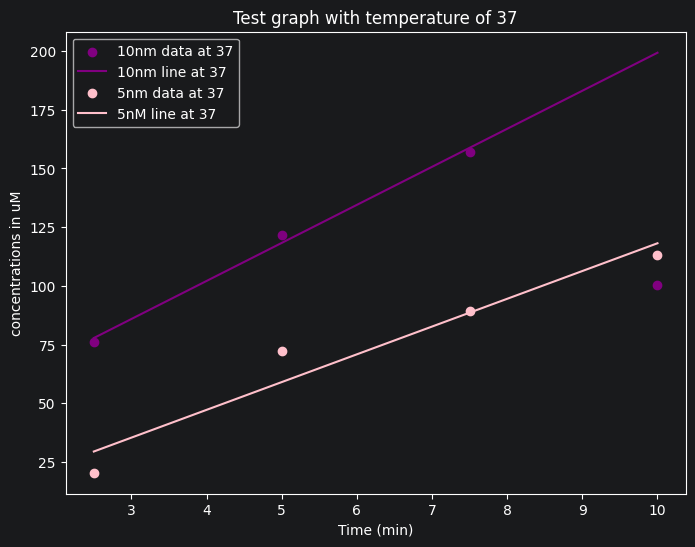

In [563]:
test_time = np.array([2.5, 5, 7.5, 10])

five_data = array_ex5_general_test[6, 9:13] - blank
ten_data = array_ex5_general_test[5, 9:13] - blank

conc_five_data = (five_data.astype(float) - pNP_inter) / pNP_slope
conc_ten_data = (ten_data.astype(float) - pNP_inter) / pNP_slope

five_slope, five_inter = np.polyfit(test_time, conc_five_data, 1)
ten_slope, ten_inter = np.polyfit(test_time[:3], conc_ten_data[:3], 1)


plt.figure(figsize=(8, 6))

plt.scatter(test_time, conc_ten_data, color ='purple', label ="10nm data at 37")
plt.plot(test_time, ten_inter + ten_slope * test_time, color ='purple', label ="10nm line at 37")

plt.scatter(test_time, conc_five_data, color ='pink', label ="5nm data at 37")
plt.plot(test_time, five_inter + five_slope * test_time, color ='pink', label ="5nM line at 37")

plt.title("Test graph with temperature of 37")
plt.ylabel("concentrations in uM")
plt.xlabel("Time (min)")
plt.legend()
plt.grid(False)
plt.show()

In [564]:
blank = np.mean(array_ex5_optimize[7, 9: 11])
data_for_optim = array_ex5_optimize[:5, 9:13]
t_ten = ((data_for_optim[0,:] - blank - pNP_inter) / pNP_slope).astype(float)
t_twenty = ((data_for_optim[1,:] - blank - pNP_inter) / pNP_slope).astype(float)
t_thirty = ((data_for_optim[2,:] - blank - pNP_inter) / pNP_slope).astype(float)
t_fourty = ((data_for_optim[3,:] - blank - pNP_inter) / pNP_slope).astype(float)
t_fifty = ((data_for_optim[4,:] - blank - pNP_inter) / pNP_slope).astype(float)

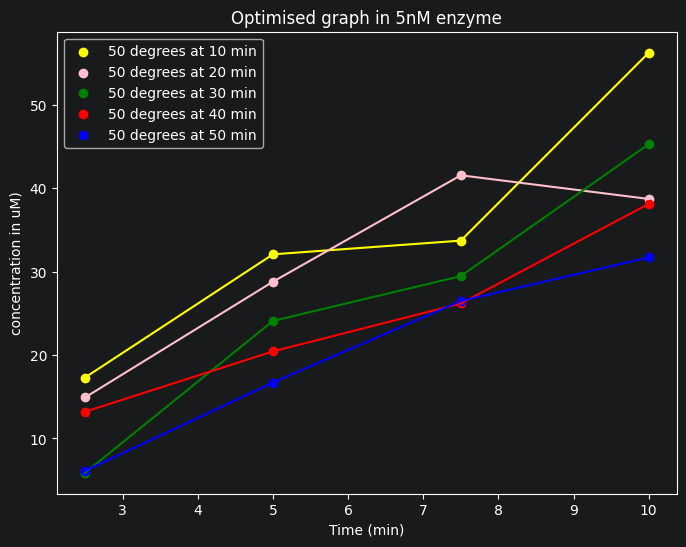

In [565]:

plt.figure(figsize=(8, 6))

plt.scatter(test_time, t_ten, color ='yellow', label ="50 degrees at 10 min")
plt.scatter(test_time, t_twenty, color ='pink', label ="50 degrees at 20 min")
plt.scatter(test_time, t_thirty, color ='green', label ="50 degrees at 30 min")
plt.scatter(test_time, t_fourty, color ='red', label ="50 degrees at 40 min")
plt.scatter(test_time, t_fifty, color ='blue', label ="50 degrees at 50 min")

plt.plot(test_time, t_ten, color ='yellow')
plt.plot(test_time, t_twenty, color ='pink')
plt.plot(test_time, t_thirty, color ='green')
plt.plot(test_time, t_fourty, color ='red')
plt.plot(test_time, t_fifty, color ='blue')


plt.title("Optimised graph in 5nM enzyme")
plt.ylabel("concentration in uM)")
plt.xlabel("Time (min)")
plt.legend()
plt.grid(False)
plt.show()

In [566]:
ten_slope, ten_inter = np.polyfit(np.delete(test_time, 2), np.delete(t_ten, 2), 1)
twenty_slope, t_twenty_inter = np.polyfit(test_time[:3], t_twenty[:3], 1)
thirty_slope, thirty_inter = np.polyfit(np.delete(test_time, 1), np.delete(t_thirty, 1), 1)
fourty_slope, fourty_inter = np.polyfit(test_time[:3], t_fourty[:3], 1)
fifty_slope, fifty_inter = np.polyfit(test_time[:3], t_fifty[:3], 1)

In [567]:

ten_activity = ten_slope / five_slope
twenty_activity = twenty_slope / five_slope
thirty_activity = thirty_slope / five_slope
fourty_activity = fourty_slope / five_slope
fifty_activity = fifty_slope / five_slope

activity = np.array([1, ten_activity, twenty_activity, thirty_activity, fourty_activity, fifty_activity])

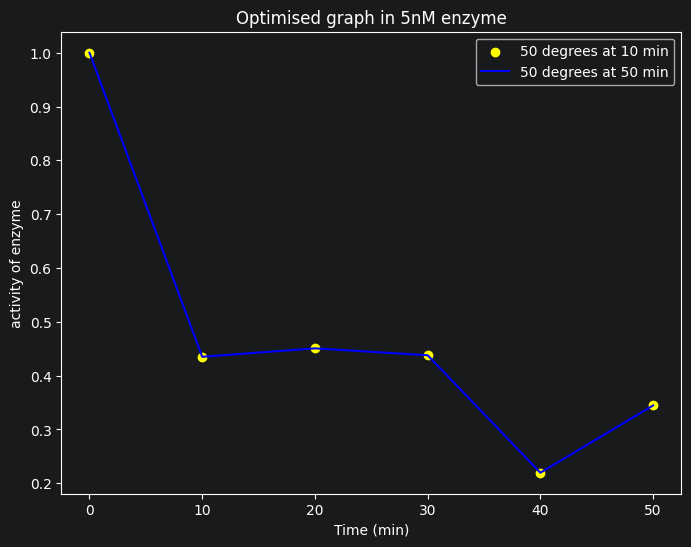

In [568]:
test_denature_time = np.array([0, 10, 20, 30, 40, 50])
plt.figure(figsize=(8, 6))

plt.scatter(test_denature_time, activity, color ='yellow', label ="50 degrees at 10 min")

plt.plot(test_denature_time, activity, color ='blue', label ="50 degrees at 50 min")


plt.title("Optimised graph in 5nM enzyme")
plt.ylabel("activity of enzyme")
plt.xlabel("Time (min)")
plt.legend()
plt.grid(False)
plt.show()

# Triplet data


In [569]:
ex_5_data = pd.read_csv("Final_5ex_data.csv", sep=";", decimal= ',')

reduced_ex5_data = ex_5_data.iloc[:, 1:]

array_ex5_data = reduced_ex5_data.to_numpy()

print(array_ex5_data)

[[9.26e-01 9.89e-01 9.12e-01 4.88e-01 2.98e-01 4.37e-01 3.88e-01 4.64e-01
  3.76e-01 5.00e-02 5.00e-02 5.00e-02 4.05e+02]
 [7.62e-01 1.09e+00 6.21e-01 5.21e-01 5.74e-01 6.14e-01 3.34e-01 4.57e-01
  3.51e-01 5.00e-02 5.00e-02 5.00e-02 4.05e+02]
 [5.00e-02 5.10e-02 5.00e-02 5.10e-02 5.10e-02 5.20e-02 5.30e-02 5.00e-02
  5.10e-02 5.10e-02 5.00e-02 5.10e-02 4.05e+02]
 [5.10e-02 5.00e-02 5.00e-02 5.10e-02 5.10e-02 5.10e-02 5.00e-02 5.10e-02
  5.10e-02 5.10e-02 5.00e-02 5.10e-02 4.05e+02]
 [5.10e-02 5.00e-02 5.00e-02 5.10e-02 5.10e-02 5.20e-02 5.50e-02 5.10e-02
  5.10e-02 5.10e-02 5.10e-02 5.10e-02 4.05e+02]
 [5.10e-02 5.40e-02 5.10e-02 5.10e-02 5.20e-02 5.10e-02 5.60e-02 5.10e-02
  5.00e-02 5.20e-02 5.70e-02 5.10e-02 4.05e+02]
 [5.10e-02 5.10e-02 5.10e-02 5.10e-02 5.10e-02 5.10e-02 5.10e-02 5.10e-02
  5.10e-02 5.10e-02 5.20e-02 5.10e-02 4.05e+02]
 [1.25e-01 1.33e-01 1.27e-01 5.20e-02 5.00e-02 5.10e-02 5.10e-02 5.10e-02
  5.00e-02 5.20e-02 5.20e-02 5.10e-02 4.05e+02]]


In [570]:
final_blank = np.mean(array_ex5_data[7, 0:3].astype(float))
abs_noBlank = array_ex5_data[:2, 0:9].astype(float) - final_blank

mean_absnoBlank = np.mean(abs_noBlank, axis = 0)

std_absnoBlank = np.std(abs_noBlank, axis = 0, ddof = 1)

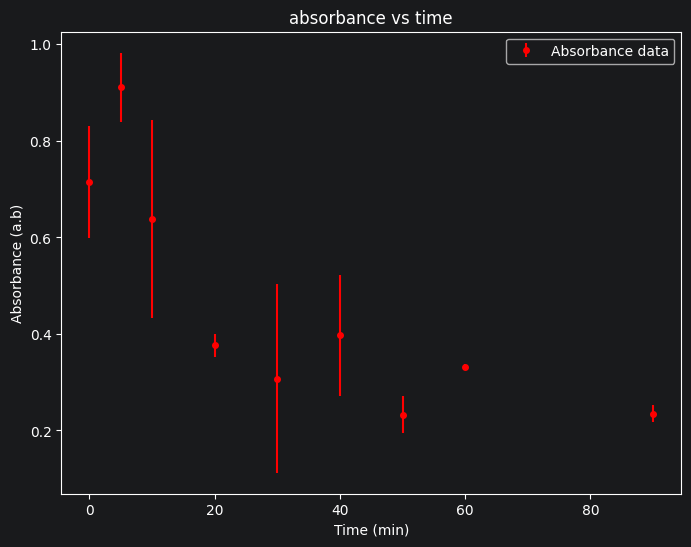

In [571]:
determined_denaturing_time = np.array([0, 5, 10, 20, 30, 40, 50, 60, 90])

plt.figure(figsize=(8, 6))

plt.errorbar(determined_denaturing_time, mean_absnoBlank, yerr = std_absnoBlank, fmt ='o', color ='red', label ="Absorbance data", markersize = 4)
plt.title("absorbance vs time")
plt.ylabel("Absorbance (a.b)")
plt.xlabel("Time (min)")
plt.legend()
plt.grid(False)
plt.show()

In [572]:
data_with_selected_start = mean_absnoBlank[1:]
std_remove_one = std_absnoBlank[1:]


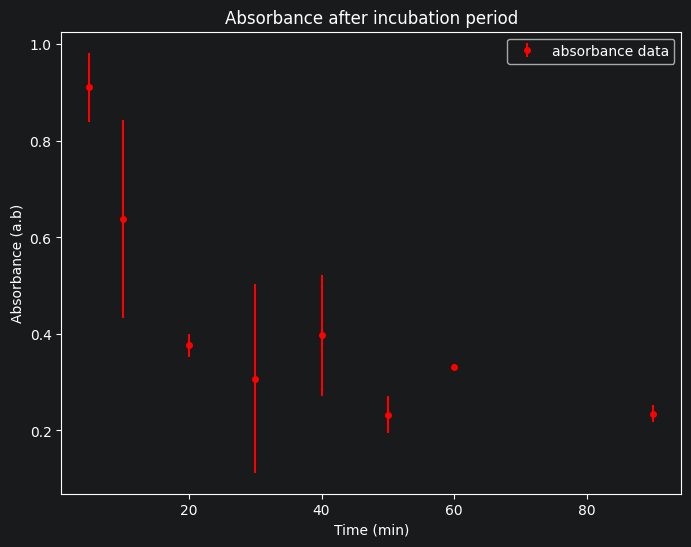

In [573]:
plt.figure(figsize=(8, 6))

plt.errorbar(determined_denaturing_time[1:], data_with_selected_start, yerr = std_remove_one, fmt ='o', color ='red', label ="absorbance data", markersize = 4)
plt.title("Absorbance after incubation period")
plt.ylabel("Absorbance (a.b)")
plt.xlabel("Time of incubation (min)")
plt.legend()
plt.grid(False)
plt.show()

In [574]:
#reaction rates must be found at each time step in mM/min
pNP_conc = (data_with_selected_start - pNP_inter) / pNP_slope

reaction_time = 5 #min
react_rate_post_incubation = pNP_conc / reaction_time

In [575]:
ratio_of_rate = react_rate_post_incubation / react_rate_post_incubation[0]
print(ratio_of_rate)

[1.         0.69653238 0.4052924  0.3291476  0.42863606 0.24577737
 0.35638187 0.24855638]


In [576]:
#std in concentration of pNP
std_pNP_data = (abs_noBlank[:, 1:] - pNP_inter) / pNP_slope
pNP_std = np.std(std_pNP_data, axis = 0, ddof = 1)

In [577]:
# Mean concentration and its SD
pNP_conc_2 = (mean_absnoBlank - pNP_inter) / pNP_slope
pNP_conc_std = std_absnoBlank / abs(pNP_slope)

# Mean reaction rate and its SD
reaction_rate = pNP_conc_2 / reaction_time
reaction_rate_std = pNP_conc_std / reaction_time

# Fractional and percentage activity
activity_fraction = reaction_rate[1:] / reaction_rate[1]
percent_activity = activity_fraction

# Error propagation for ratio to time-zero rate
percent_activity_std = percent_activity * np.sqrt(
    (reaction_rate_std[1:] / reaction_rate[1:]) ** 2
    + (reaction_rate_std[1] / reaction_rate[1]) ** 2
)

# The time-zero value was divided by itself, so it is exactly 100%
# under this normalization.
percent_activity_std[0] = 0

print("Percentage activity:")
print(percent_activity)

print("\nEstimated SD of percentage activity:")
print(percent_activity_std)

Percentage activity:
[1.         0.69653238 0.4052924  0.3291476  0.42863606 0.24577737
 0.35638187 0.24855638]

Estimated SD of percentage activity:
[0.         0.23532151 0.04132888 0.2185101  0.14322697 0.04671515
 0.02882257 0.02784805]


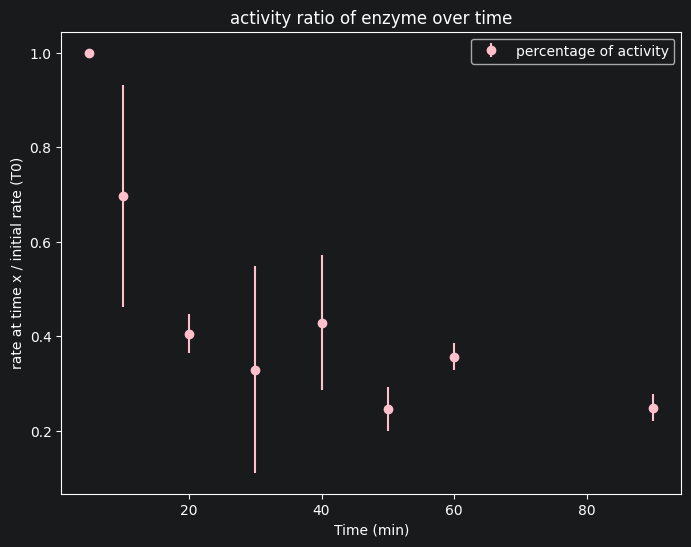

In [578]:
plt.figure(figsize=(8, 6))
plt.errorbar(determined_denaturing_time[1:], ratio_of_rate, yerr = percent_activity_std, fmt ='o', color ='pink', label ="percentage of activity")
plt.title("activity ratio of enzyme over time")
plt.ylabel("rate at time x / initial rate (T0)")
plt.xlabel("Time of incubation (min)")
plt.legend()
plt.grid(False)
plt.show()

In [579]:
nature_log_rate = np.log(ratio_of_rate)
# Defining the standard error using cov:
(slope_nature_log_rate, inter_nature_log_rate),cov = np.polyfit(determined_denaturing_time[1:], nature_log_rate, 1, cov = True)


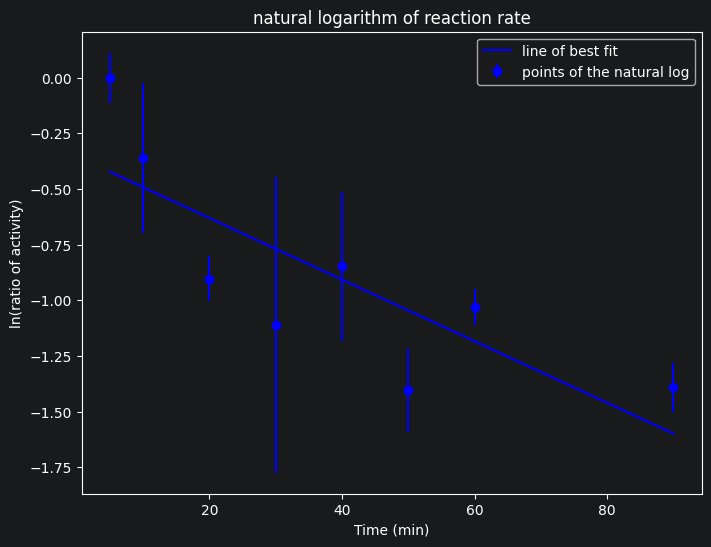

In [580]:
plt.figure(figsize=(8, 6))
std_ln = []
for i in range(len(pNP_conc)):
    std_ln.append((((pNP_std[0]/pNP_conc[0])**2)+((pNP_std[i]/pNP_conc[i])**2))**(1/2))

sol_std_ln = np.array(std_ln)



plt.errorbar(determined_denaturing_time[1:], nature_log_rate, yerr = sol_std_ln, fmt ='o', color ='blue', label ="points of the natural log")
plt.plot(determined_denaturing_time[1:], inter_nature_log_rate + slope_nature_log_rate * determined_denaturing_time[1:], color ='blue', label ="line of best fit")
plt.title("natural logarithm of reaction rate ratio")
plt.ylabel("ln(ratio of activity)")
plt.xlabel("Time of incubation (min)")
plt.legend()
plt.grid(False)
plt.show()

In [581]:
print(np.array([std_ln]))

[[0.1122719  0.33784719 0.10197301 0.66386662 0.33414586 0.19007101
  0.08087552 0.11203915]]


In [582]:
K_inact = -slope_nature_log_rate

T_half = np.log(2) / K_inact

Err_K_inact = np.sqrt(cov[0,0])
# Error propagation rule:
Err_t_half = np.log(2) / K_inact**2 * Err_K_inact
#print(Err_t_half)

print(f"The inactivation constant is: {K_inact:.4f} +/- {Err_K_inact:.6f} min^-1, and the half life is {T_half:.3f} +/- {Err_t_half:.3f} min")

The inactivation constant is: 0.0138 +/- 0.004174 min^-1, and the half life is 50.079 +/- 15.102 min


In [583]:
from scipy.stats import linregress
res_logged_ratio = linregress(determined_denaturing_time[1:], ratio_of_rate)
logged_activity_R = res_logged_ratio.rvalue
logged_activity_R2 = logged_activity_R ** 2
logged_activity_R2_percentage = logged_activity_R2 * 100

print(f"R value for the logged concentration ratio: {logged_activity_R2 :.2f}")
print(f"R^2 value for the logged concentration ratio: {logged_activity_R2_percentage:.2f}%")


R value for the logged concentration ratio: 0.56
R^2 value for the logged concentration ratio: 55.85%
